# Proyeksi Penjualan UMKM

## Pendahuluan
Pada notebook ini, kita akan membangun model prediksi untuk proyeksi penjualan UMKM menggunakan metode machine learning. Model ini akan membantu UMKM dalam merencanakan strategi produksi, pemasaran, dan stok.

## Langkah 1: Memuat Dataset
Pada langkah ini, kita akan memuat dataset yang berisi data historis mengenai anggaran iklan dan penjualan. Data ini akan digunakan untuk melatih model prediksi penjualan berbasis AI.

In [ ]:

import pandas as pd
import numpy as np

# Load the dataset
dummy_df = pd.read_excel('7_proyeksi_umkm.xlsx')
dummy_df


,Year,Month,Advertising Budget (IDR Thousand),Sales (IDR Thousand)
0,2023,4,980.768159,5081.203351
1,2021,9,436.867090,4438.120903
2,2021,7,115.764392,1585.155600
3,2022,1,319.732561,3924.731991
4,2023,12,847.789472,3651.330722
...,...,...,...,...
295,2023,5,967.440048,6847.205795
296,2021,6,323.722232,2170.787195
297,2021,2,220.423363,2758.747169
298,2022,1,476.722559,3894.901234


## Langkah 2: Visualisasi Data
Selanjutnya, kita akan melakukan visualisasi untuk memahami hubungan antara anggaran iklan dan penjualan. Hal ini akan membantu kita memahami pola dasar dalam dataset.

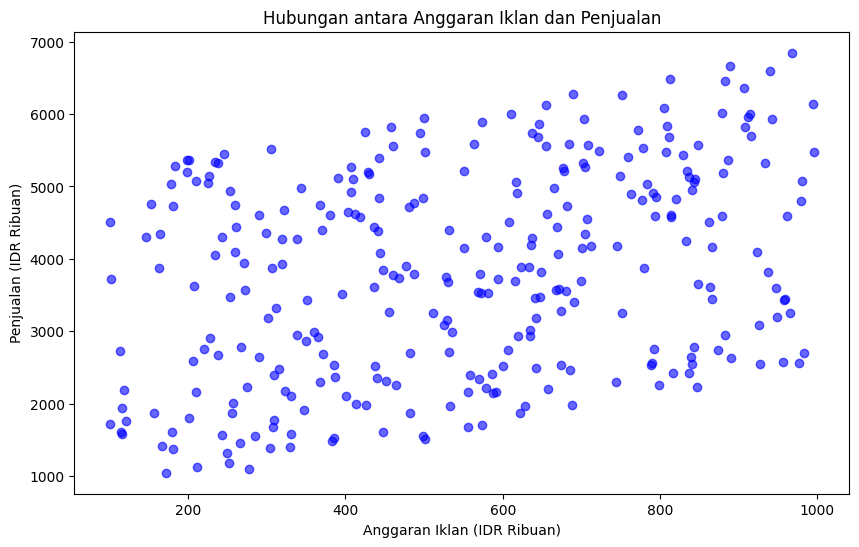

In [ ]:

import matplotlib.pyplot as plt

# Plotting the relationship between Advertising Budget and Sales
plt.figure(figsize=(10, 6))
plt.scatter(dummy_df["Advertising Budget (IDR Thousand)"], dummy_df["Sales (IDR Thousand)"], color='blue', alpha=0.6)
plt.title("Hubungan antara Anggaran Iklan dan Penjualan")
plt.xlabel("Anggaran Iklan (IDR Ribuan)")
plt.ylabel("Penjualan (IDR Ribuan)")
plt.show()


## Langkah 3: Preprocessing Data
Sebelum melatih model, data perlu diproses terlebih dahulu, termasuk memilih fitur yang relevan dan memastikan bahwa data tersebut dalam format yang sesuai untuk pelatihan.

In [ ]:

from sklearn.preprocessing import MinMaxScaler

# Selecting features (X) and target variable (y)
X = dummy_df[["Advertising Budget (IDR Thousand)"]]
y = dummy_df["Sales (IDR Thousand)"]

# Feature scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Show the first few rows of the scaled data
X_scaled[:5]


array([[0.98306865],
       [0.37578759],
       [0.01726727],
       [0.24500355],
       [0.83459415]])

## Langkah 4: Pembagian Data Train dan Test
Setelah preprocessing, kita akan membagi dataset menjadi dua bagian: satu untuk pelatihan model (train) dan satu lagi untuk menguji akurasi model (test). Pembagian ini penting untuk mengevaluasi kinerja model.

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Display the shape of the train and test sets
X_train.shape, X_test.shape


((210, 1), (90, 1))

## Langkah 5: Melatih Model
Kita akan melatih model menggunakan algoritma Linear Regression untuk memprediksi penjualan berdasarkan anggaran iklan. Algoritma ini cocok untuk masalah regresi di mana kita memprediksi nilai kontinu.

In [ ]:
from sklearn.linear_model import LinearRegression
# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Check the accuracy on the training data
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

train_score, test_score


(0.09566127425478566, 0.12497566148423833)

## Langkah 6: Evaluasi Model
Setelah melatih model, kita akan mengevaluasi kinerjanya menggunakan metrik seperti Mean Squared Error (MSE) dan R-squared (R²) untuk mengetahui seberapa baik model dalam memprediksi penjualan.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2


(1989418.0100207601, 0.12497566148423833)

## Langkah 7: Prediksi
Setelah model dilatih, kita dapat menggunakannya untuk memprediksi penjualan berdasarkan anggaran iklan yang baru. Prediksi ini dapat membantu UMKM dalam perencanaan produksi dan pemasaran.

In [ ]:

# Example prediction for a new observation (e.g., new advertising budget)
new_data = np.array([[800]])  # Example new data (Advertising Budget = 800 IDR Thousand)

# Scale the new data
new_data_scaled = scaler.transform(new_data)

# Predict sales
sales_prediction = model.predict(new_data_scaled)
sales_prediction


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([4310.98822197])


## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
